In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import boto3
from botocore.config import Config
import os

endpoint_url=os.environ["S3_ENDPOINT_URL"]

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
storage_options = {
    "client_kwargs": {"endpoint_url": endpoint_url},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [ ]:
ds = xr.open_dataset('/tmp/ZI_mel_2015_2025.nc')
ds.to_zarr('s3://gaia/cjense/data/melange/ZI_mel_2015_2025.zarr', consolidated=False, storage_options=storage_options)

In [5]:
melange = xr.open_dataset('s3://gaia/cjense/data/melange/ZI_mel_2015_2025.zarr', storage_options=storage_options, consolidated=False)

In [6]:
melange

<xarray.Dataset> Size: 10GB
Dimensions:                (time: 462, y: 1120, x: 1600)
Coordinates:
  * time                   (time) datetime64[ns] 4kB 2015-01-25 ... 2025-06-07
  * y                      (y) float64 9kB -1.067e+06 -1.067e+06 ... -1.123e+06
  * x                      (x) float64 13kB 4.6e+05 4.601e+05 ... 5.4e+05
Data variables:
    duration               (time) float64 4kB ...
    spatial_ref            int64 8B ...
    time1                  (time) datetime64[ns] 4kB ...
    time2                  (time) datetime64[ns] 4kB ...
    masked_mel_velocity    (time, y, x) float32 3GB ...
    velocity               (time, y, x) float32 3GB ...
    velocity_over_melange  (time, y, x) float32 3GB ...

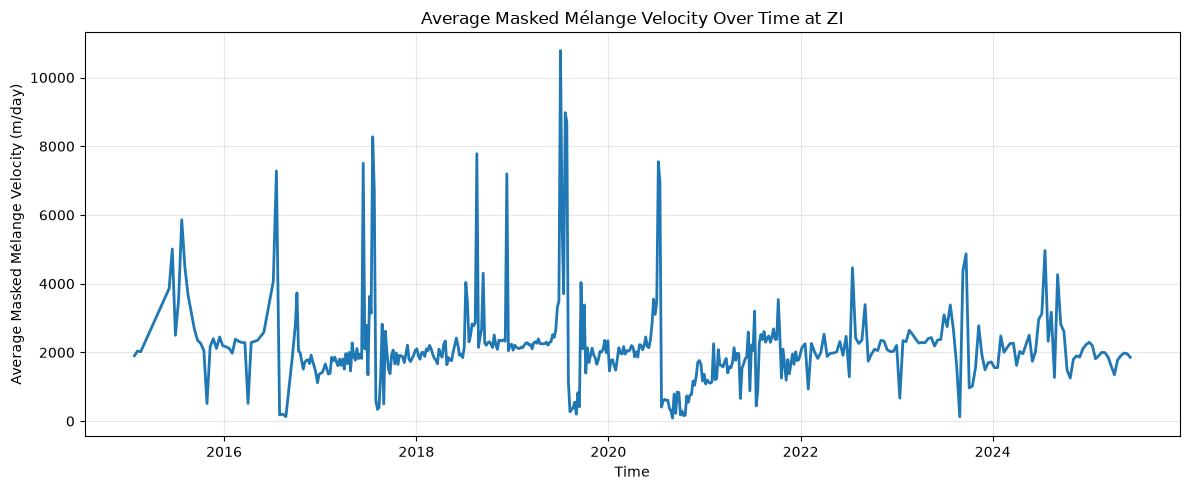

In [13]:
# Plot average masked_mel_velocity over space
avg_velocity = melange['masked_mel_velocity'].mean(dim=['y', 'x'])

fig, ax = plt.subplots(figsize=(12, 5))
avg_velocity.plot(ax=ax, linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Average Masked Mélange Velocity (m/day)')
ax.set_title('Average Masked Mélange Velocity Over Time at ZI')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/melvel_overtime_ZI.png', dpi=300)

plt.show()

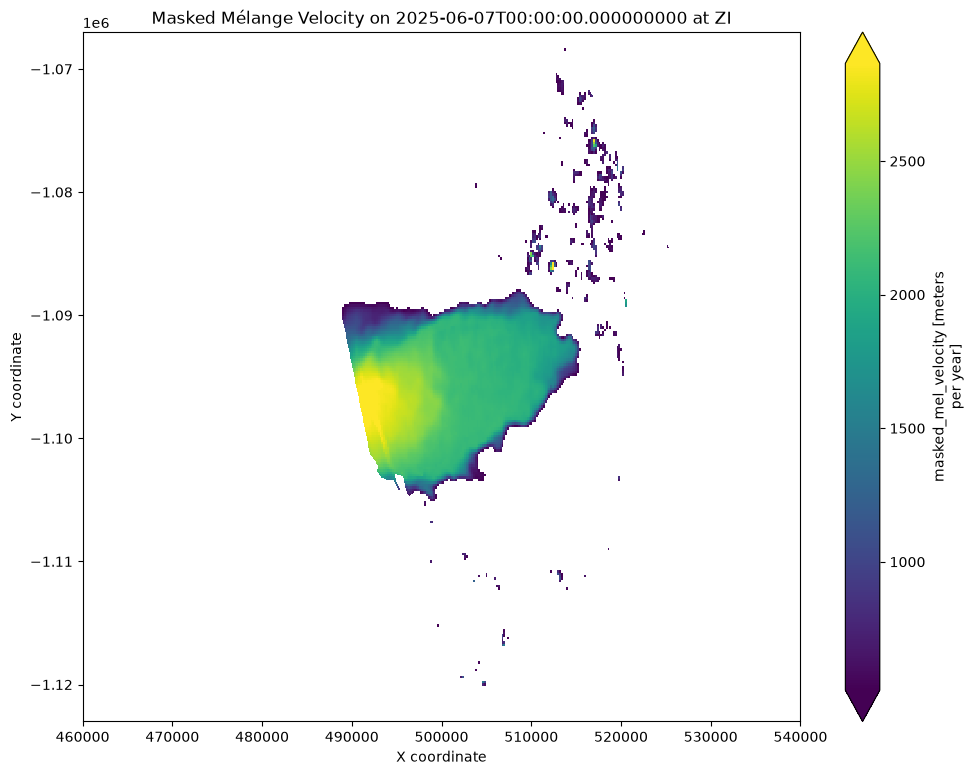

In [14]:
# Plot spatial distribution at a single time
# Using the latest date in the dataset
time_idx = -1
data_at_time = melange['masked_mel_velocity'].isel(time=time_idx)

fig, ax = plt.subplots(figsize=(10, 8))
data_at_time.plot(ax=ax, cmap='viridis', robust=True)
ax.set_title(f'Masked Mélange Velocity on {melange.time.isel(time=time_idx).values} at ZI')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
plt.tight_layout()

plt.savefig('figures/melvel_20250607_ZI.png', dpi=300)
plt.show()